# Model Selection and Tuning

This notebook performs detailed analysis and optimization of the model configurations selected during baseline screening.

The shortlisted models are:

- Balanced CatBoost
- Balanced Random Forest
- Balanced XGBoost

Model development continues to use expanding-window temporal validation over 2020-2023. The 2024 final holdout remains sealed and is not loaded or inspected.

## Setup

### Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from itertools import product
from catboost.utils import get_gpu_device_count
from tqdm import tqdm

### Project Path

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

### Project Imports

In [3]:
from src.data import load_development_data

from src.features import (
    build_features,
    TARGET,
    YEAR,
    PRIMARY_FEATURES,
)

### Compute Device

GPU acceleration is enabled when supported efficiently by the model and data representation.

CatBoost uses GPU acceleration when available. XGBoost uses CPU execution for the one-hot encoded sparse feature representation used in this notebook.

In [4]:
GPU_COUNT = get_gpu_device_count()
USE_GPU = GPU_COUNT > 0
COMPUTE_DEVICE = "GPU" if USE_GPU else "CPU"

CATBOOST_DEVICE_PARAMS = (
    {
        "task_type": "GPU",
        "devices": "0",
    }
    if USE_GPU
    else {
        "task_type": "CPU",
    }
)

XGBOOST_DEVICE_PARAMS = {
    "device": "cpu",
}

print(f"Available compute device: {COMPUTE_DEVICE}")
print(
    "CatBoost device: "
    f"{'GPU' if USE_GPU else 'CPU'}"
)
print("XGBoost device: CPU")

Available compute device: GPU
CatBoost device: GPU
XGBoost device: CPU


## Development Data

Only the 2020-2023 development period is used for model selection and tuning.

In [5]:
train_df = load_development_data()
features_df = build_features(train_df)

### Validation

In [6]:
print("Raw shape:", train_df.shape)
print(
    "Feature-engineered shape:",
    features_df.shape,
)
print(
    "Years:",
    sorted(features_df[YEAR].unique()),
)

assert set(
    features_df[YEAR].unique()
) == {
    2020,
    2021,
    2022,
    2023,
}

assert len(features_df) == len(train_df)

Raw shape: (41626, 46)
Feature-engineered shape: (41626, 63)
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


## Modeling Dataset

### Target Encoding

The CBS severity codes are mapped to zero-based model labels while preserving their original meaning.

In [7]:
TARGET_MAPPING = {
    1: 0,  # Fatal
    2: 1,  # Serious
    3: 2,  # Slight
}

CLASS_LABELS = [0, 1, 2]

In [8]:
X = features_df[
    PRIMARY_FEATURES
].copy()

y = (
    features_df[TARGET]
    .map(TARGET_MAPPING)
    .astype(int)
)

years = features_df[
    YEAR
].copy()

### Validation

In [9]:
assert len(X) == len(y) == len(years)

assert set(y.unique()) == {
    0,
    1,
    2,
}

assert TARGET not in X.columns
assert YEAR not in X.columns

### Categorical Representation

The primary predictors use the same categorical representation as in baseline screening.

In [10]:
def prepare_categorical_features(
    df: pd.DataFrame,
) -> pd.DataFrame:
    result = df.copy()

    for column in result.columns:
        result[column] = result[column].map(
            lambda value:
                str(value)
                if pd.notna(value)
                else np.nan
        )

    return result

In [11]:
X = prepare_categorical_features(X)

### Validation

In [12]:
assert len(X) == len(y) == len(years)

assert set(y.unique()) == {
    0,
    1,
    2,
}

assert TARGET not in X.columns
assert YEAR not in X.columns

## Temporal Cross-Validation

The same expanding-window temporal folds used during model screening are retained so that all subsequent results remain directly comparable.

In [13]:
TEMPORAL_FOLDS = [
    {
        "name": "2020 -> 2021",
        "train_years": [2020],
        "validation_year": 2021,
    },
    {
        "name": "2020-2021 -> 2022",
        "train_years": [
            2020,
            2021,
        ],
        "validation_year": 2022,
    },
    {
        "name": "2020-2022 -> 2023",
        "train_years": [
            2020,
            2021,
            2022,
        ],
        "validation_year": 2023,
    },
]

### Validation

In [14]:
for fold in TEMPORAL_FOLDS:
    train_mask = years.isin(
        fold["train_years"]
    )
    validation_mask = years.eq(
        fold["validation_year"]
    )

    print(
        fold["name"],
        "| Train:",
        train_mask.sum(),
        "| Validation:",
        validation_mask.sum(),
    )

    assert (
        max(fold["train_years"])
        < fold["validation_year"]
    )

2020 -> 2021 | Train: 10836 | Validation: 11554
2020-2021 -> 2022 | Train: 22390 | Validation: 10404
2020-2022 -> 2023 | Train: 32794 | Validation: 8832


## Evaluation Helpers

### Metric Calculation Helper

The same evaluation metrics used during model screening are retained for detailed analysis.

In [15]:
def calculate_metrics(
    y_true,
    y_pred,
) -> dict:
    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=CLASS_LABELS,
            average="weighted",
            zero_division=0,
        ),
    }

### Detailed Temporal Evaluation Helper

Each model is evaluated on both training and validation data. The fitted model from each fold is also retained for subsequent diagnostic analysis.

In [16]:
def evaluate_detailed_temporal_cv(
    model,
    model_name,
    X,
    y,
    years,
    fit_params=None,
    fit_params_factory=None,
):
    fold_results = []
    predictions = []
    fitted_models = {}

    for fold in TEMPORAL_FOLDS:
        train_mask = years.isin(
            fold["train_years"]
        )
        validation_mask = years.eq(
            fold["validation_year"]
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        X_validation = X.loc[
            validation_mask
        ]
        y_validation = y.loc[
            validation_mask
        ]

        fold_model = clone(model)

        current_fit_params = dict(
            fit_params or {}
        )

        if fit_params_factory is not None:
            current_fit_params.update(
                fit_params_factory(
                    y_train
                )
            )

        fold_model.fit(
            X_train,
            y_train,
            **current_fit_params,
        )

        train_pred = np.asarray(
            fold_model.predict(
                X_train
            )
        ).ravel()

        validation_pred = np.asarray(
            fold_model.predict(
                X_validation
            )
        ).ravel()

        train_metrics = calculate_metrics(
            y_train,
            train_pred,
        )

        validation_metrics = calculate_metrics(
            y_validation,
            validation_pred,
        )

        fold_results.append({
            "model": model_name,
            "fold": fold["name"],
            "train_rows": len(X_train),
            "validation_rows":
                len(X_validation),
            **{
                f"train_{metric}": value
                for metric, value
                in train_metrics.items()
            },
            **{
                f"validation_{metric}": value
                for metric, value
                in validation_metrics.items()
            },
            "macro_f1_gap":
                train_metrics["macro_f1"]
                - validation_metrics["macro_f1"],
        })

        predictions.append(
            pd.DataFrame({
                "model": model_name,
                "fold": fold["name"],
                "split": "train",
                "year": years.loc[
                    train_mask
                ].to_numpy(),
                "y_true":
                    y_train.to_numpy(),
                "y_pred": train_pred,
            })
        )

        predictions.append(
            pd.DataFrame({
                "model": model_name,
                "fold": fold["name"],
                "split": "validation",
                "year": years.loc[
                    validation_mask
                ].to_numpy(),
                "y_true":
                    y_validation.to_numpy(),
                "y_pred":
                    validation_pred,
            })
        )

        fitted_models[
            fold["name"]
        ] = fold_model

    return (
        pd.DataFrame(fold_results),
        pd.concat(
            predictions,
            ignore_index=True,
        ),
        fitted_models,
    )

### Train vs Validation Summary Helper

In [17]:
SUMMARY_METRICS = [
    "accuracy",
    "macro_f1",
    "weighted_f1",
]


def summarize_train_validation(
    results: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for metric in SUMMARY_METRICS:
        train_mean = results[
            f"train_{metric}"
        ].mean()

        validation_mean = results[
            f"validation_{metric}"
        ].mean()

        rows.append({
            "metric": metric,
            "train_mean": train_mean,
            "validation_mean":
                validation_mean,
            "gap":
                train_mean
                - validation_mean,
        })

    return (
        pd.DataFrame(rows)
        .set_index("metric")
    )

### CatBoost Learning Curves Helpers

Helper functions collect and visualize train and validation Macro F1 across CatBoost boosting iterations to examine convergence and the train-validation gap.

In [18]:
def collect_catboost_learning_curves(
    fitted_models,
    X,
    y,
    years,
) -> pd.DataFrame:
    curves = []

    for fold in TEMPORAL_FOLDS:
        fold_name = fold["name"]

        train_mask = years.isin(
            fold["train_years"]
        )
        validation_mask = years.eq(
            fold["validation_year"]
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        X_validation = X.loc[
            validation_mask
        ]
        y_validation = y.loc[
            validation_mask
        ]

        fold_model = fitted_models[
            fold_name
        ]

        train_predictions = (
            fold_model.staged_predict(
                X_train,
                prediction_type="Class",
            )
        )

        validation_predictions = (
            fold_model.staged_predict(
                X_validation,
                prediction_type="Class",
            )
        )

        for iteration, (
            train_pred,
            validation_pred,
        ) in enumerate(
            zip(
                train_predictions,
                validation_predictions,
            ),
            start=1,
        ):
            train_pred = np.asarray(
                train_pred
            ).ravel()

            validation_pred = np.asarray(
                validation_pred
            ).ravel()

            curves.append({
                "fold": fold_name,
                "iteration": iteration,
                "train_macro_f1":
                    f1_score(
                        y_train,
                        train_pred,
                        labels=CLASS_LABELS,
                        average="macro",
                        zero_division=0,
                    ),
                "validation_macro_f1":
                    f1_score(
                        y_validation,
                        validation_pred,
                        labels=CLASS_LABELS,
                        average="macro",
                        zero_division=0,
                    ),
            })

    return pd.DataFrame(curves)

In [19]:
def plot_catboost_learning_curves(
    learning_curves: pd.DataFrame,
    metric: str,
    metric_label: str,
):
    for fold_name in (
        learning_curves["fold"]
        .drop_duplicates()
    ):
        fold_data = learning_curves[
            learning_curves["fold"]
            == fold_name
        ]

        plt.figure(figsize=(9, 5))

        plt.plot(
            fold_data["iteration"],
            fold_data[
                f"train_{metric}"
            ],
            label="Train",
        )

        plt.plot(
            fold_data["iteration"],
            fold_data[
                f"validation_{metric}"
            ],
            label="Validation",
        )

        plt.xlabel("Boosting Iteration")
        plt.ylabel(metric_label)

        plt.title(
            "Balanced CatBoost: "
            f"{fold_name}"
        )

        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

In [20]:
def summarize_learning_curves(
    learning_curves: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for fold_name, fold_data in (
        learning_curves.groupby(
            "fold",
            sort=False,
        )
    ):
        best_index = (
            fold_data[
                "validation_macro_f1"
            ]
            .idxmax()
        )

        best_row = fold_data.loc[
            best_index
        ]

        final_row = fold_data.iloc[-1]

        rows.append({
            "fold": fold_name,
            "best_iteration":
                int(
                    best_row[
                        "iteration"
                    ]
                ),
            "best_validation_macro_f1":
                best_row[
                    "validation_macro_f1"
                ],
            "final_validation_macro_f1":
                final_row[
                    "validation_macro_f1"
                ],
            "difference":
                best_row[
                    "validation_macro_f1"
                ]
                - final_row[
                    "validation_macro_f1"
                ],
        })

    return pd.DataFrame(rows)

### Train vs Validation Plot

A reusable plot compares training and validation performance across the temporal folds.

In [21]:
def plot_train_validation_by_fold(
    results: pd.DataFrame,
    model_name: str,
    metric: str = "macro_f1",
    metric_label: str = "Macro F1",
):
    plt.figure(figsize=(9, 5))

    plt.plot(
        results["fold"],
        results[f"train_{metric}"],
        marker="o",
        label="Train",
    )

    plt.plot(
        results["fold"],
        results[f"validation_{metric}"],
        marker="o",
        label="Validation",
    )

    plt.xlabel("Temporal Fold")
    plt.ylabel(metric_label)

    plt.title(
        f"{model_name}: Train vs Validation {metric_label}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### XGBoost Helpers

In [22]:
def build_balanced_xgboost_fit_params(
    y_train,
) -> dict:
    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )

    return {
        "classifier__sample_weight":
            sample_weights
    }

## Preprocessing

### One-Hot Encoded Models

Balanced Random Forest and Balanced XGBoost use missing-value imputation followed by one-hot encoding.

In [23]:
categorical_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing",
        ),
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
        ),
    ),
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_preprocessor,
            PRIMARY_FEATURES,
        ),
    ],
    remainder="drop",
)

### Native Categorical Model

CatBoost uses the categorical predictors directly, with missing values represented explicitly as `Missing`.

In [24]:
X_catboost = (
    X
    .fillna("Missing")
    .copy()
)

#### Validation

In [25]:
assert not X_catboost.isna().any().any()

assert all(
    isinstance(value, str)
    for column in X_catboost.columns
    for value in X_catboost[column]
)

## Shortlisted Model Analysis

The shortlisted models are analyzed in greater detail before hyperparameter tuning.


### Balanced CatBoost

Balanced CatBoost achieved the highest mean Macro F1 during the previous baseline-screening notebook and is analyzed first here. All shortlisted models in this notebook, including CatBoost, are re-evaluated using the compute backend described above.

#### Model Definition

In [26]:
balanced_catboost_model = CatBoostClassifier(
    iterations=500,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    **CATBOOST_DEVICE_PARAMS,
)

#### Detailed Temporal Evaluation

In [27]:
(
    balanced_catboost_results,
    balanced_catboost_predictions,
    balanced_catboost_models,
) = evaluate_detailed_temporal_cv(
    model=balanced_catboost_model,
    model_name="Balanced CatBoost",
    X=X_catboost,
    y=y,
    years=years,
    fit_params={
        "cat_features":
            list(X_catboost.columns),
    },
)

In [28]:
balanced_catboost_results[
    [
        "fold",
        "train_macro_f1",
        "validation_macro_f1",
        "macro_f1_gap",
    ]
].round(3)

,fold,train_macro_f1,validation_macro_f1,macro_f1_gap
0,2020 -> 2021,0.730,0.465,0.265
1,2020-2021 -> 2022,0.634,0.476,0.157
2,2020-2022 -> 2023,0.637,0.507,0.130


In [29]:
balanced_catboost_summary = (
    summarize_train_validation(
        balanced_catboost_results
    )
)

balanced_catboost_summary.round(3)

,train_mean,validation_mean,gap
metric,,,
accuracy,0.795,0.703,0.093
macro_f1,0.667,0.483,0.184
weighted_f1,0.809,0.717,0.092


#### Learning Curves

Macro F1 is tracked after every boosting iteration to examine model convergence and the development of the train-validation gap.

In [30]:
balanced_catboost_learning_curves = (
    collect_catboost_learning_curves(
        fitted_models=
            balanced_catboost_models,
        X=X_catboost,
        y=y,
        years=years,
    )
)

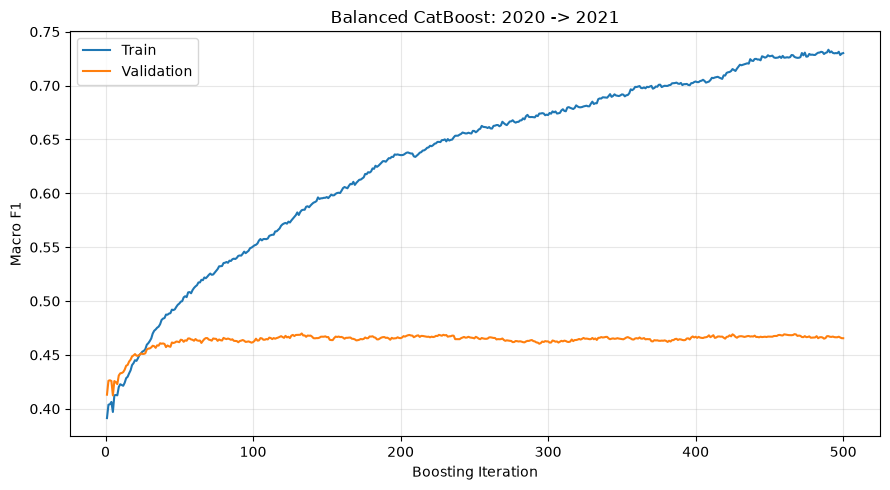

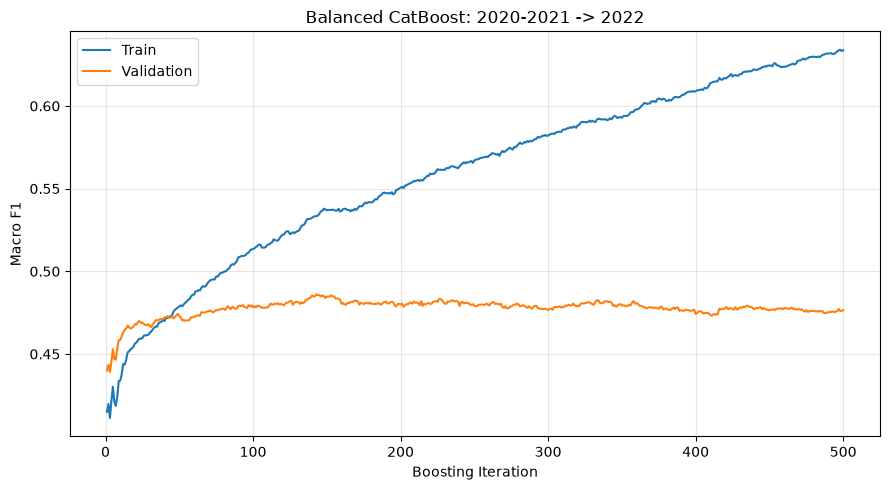

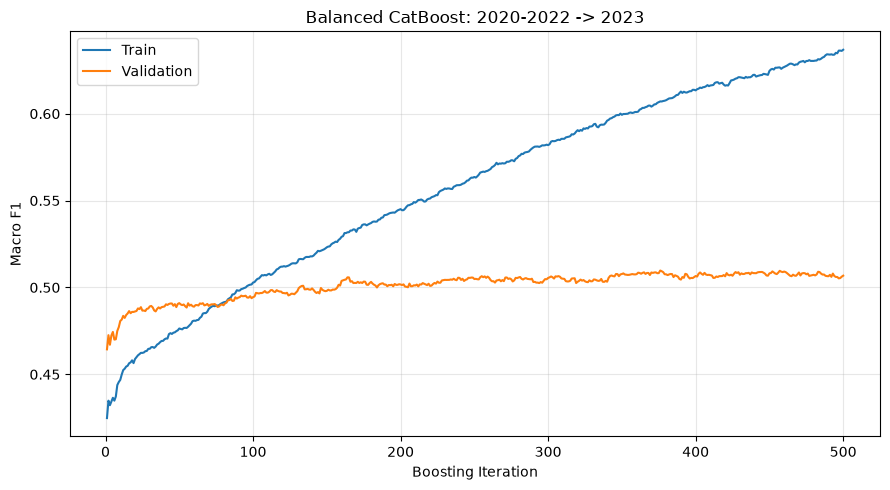

In [31]:
plot_catboost_learning_curves(
    learning_curves=
        balanced_catboost_learning_curves,
    metric="macro_f1",
    metric_label="Macro F1",
)

In [32]:
catboost_learning_summary = (
    summarize_learning_curves(
        balanced_catboost_learning_curves
    )
)

catboost_learning_summary.round(4)

,fold,best_iteration,best_validation_macro_f1,final_validation_macro_f1,difference
0,2020 -> 2021,133,0.4699,0.4655,0.0044
1,2020-2021 -> 2022,143,0.4860,0.4765,0.0095
2,2020-2022 -> 2023,376,0.5097,0.5068,0.0030


#### Interpretation

Training Macro F1 continues to increase throughout boosting, while validation performance gradually approaches a plateau.

The best validation iteration occurs well before the 500-iteration ceiling in every fold (133, 143, and 376), and the difference between the best observed Macro F1 and the score at the final iteration is small, at most 0.0095.

This suggests that the current 500-iteration ceiling is not limiting performance in any fold, and that early stopping could reduce training time without a meaningful loss in validation Macro F1.

Boosting iterations and early stopping are explored more systematically during hyperparameter tuning.

### Balanced Random Forest

Balanced Random Forest achieved the second-highest mean Macro F1 during model screening and is evaluated for train-validation generalization.

#### Model Definition

The same Balanced Random Forest configuration used during model screening is retained for detailed analysis.

In [33]:
balanced_random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor,
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

#### Detailed Temporal Evaluation

Training and validation performance are compared across the same temporal folds used during model screening.

In [34]:
(
    balanced_random_forest_results,
    balanced_random_forest_predictions,
    balanced_random_forest_models,
) = evaluate_detailed_temporal_cv(
    model=balanced_random_forest_model,
    model_name="Balanced Random Forest",
    X=X,
    y=y,
    years=years,
)

In [35]:
balanced_random_forest_results[
    [
        "fold",
        "train_macro_f1",
        "validation_macro_f1",
        "macro_f1_gap",
    ]
].round(3)

,fold,train_macro_f1,validation_macro_f1,macro_f1_gap
0,2020 -> 2021,0.991,0.481,0.510
1,2020-2021 -> 2022,0.989,0.496,0.494
2,2020-2022 -> 2023,0.987,0.505,0.483


#### Train vs Validation Summary

In [36]:
balanced_random_forest_summary = (
    summarize_train_validation(
        balanced_random_forest_results
    )
)

balanced_random_forest_summary.round(3)

,train_mean,validation_mean,gap
metric,,,
accuracy,0.991,0.767,0.224
macro_f1,0.989,0.494,0.495
weighted_f1,0.991,0.753,0.239


#### Train vs Validation

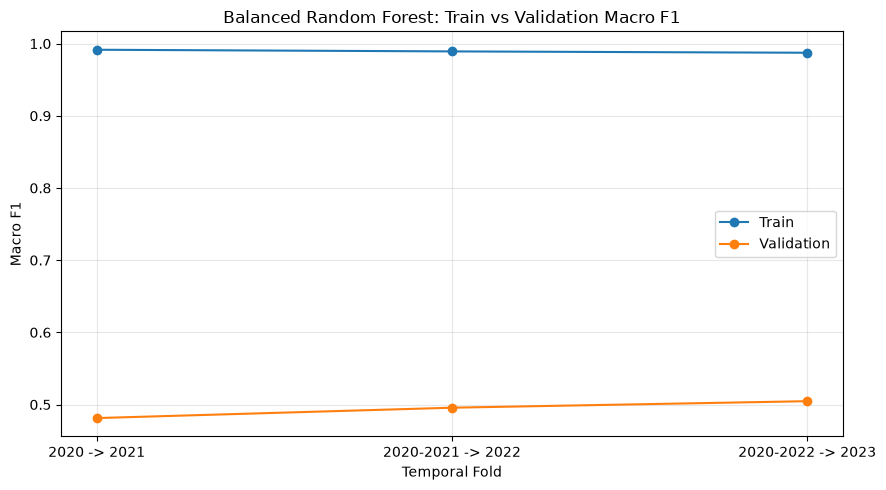

In [37]:
plot_train_validation_by_fold(
    results=balanced_random_forest_results,
    model_name="Balanced Random Forest",
    metric="macro_f1",
    metric_label="Macro F1",
)

#### Interpretation

Balanced Random Forest shows substantial overfitting across all temporal folds.

Training Macro F1 remains close to 0.99, while validation Macro F1 ranges from 0.481 to 0.505, resulting in a train-validation gap of approximately 0.5.

Validation performance improves as more historical data becomes available, and the gap decreases slightly, but the generalization gap remains very large.

The model therefore requires substantially stronger regularization if it is selected for hyperparameter tuning.

### Balanced XGBoost

Balanced XGBoost achieved competitive Macro F1 during model screening and is evaluated for train-validation generalization across the temporal folds.

#### Model Definition

The same Balanced XGBoost configuration used during model screening is retained. Class balancing is applied through training sample weights calculated separately within each temporal fold.

In [38]:
balanced_xgboost_model = Pipeline([
    (
        "preprocessor",
        preprocessor,
    ),
    (
        "classifier",
        XGBClassifier(
            n_estimators=500,
            learning_rate=0.1,
            max_depth=6,
            objective="multi:softprob",
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
            **XGBOOST_DEVICE_PARAMS,
        ),
    ),
])

#### Detailed Temporal Evaluation

Training and validation performance are compared across the temporal folds using fold-specific class-balanced sample weights.

In [39]:
(
    balanced_xgboost_results,
    balanced_xgboost_predictions,
    balanced_xgboost_models,
) = evaluate_detailed_temporal_cv(
    model=balanced_xgboost_model,
    model_name="Balanced XGBoost",
    X=X,
    y=y,
    years=years,
    fit_params_factory=
        build_balanced_xgboost_fit_params,
)

In [40]:
balanced_xgboost_results[
    [
        "fold",
        "train_macro_f1",
        "validation_macro_f1",
        "macro_f1_gap",
    ]
].round(3)

,fold,train_macro_f1,validation_macro_f1,macro_f1_gap
0,2020 -> 2021,0.854,0.475,0.379
1,2020-2021 -> 2022,0.738,0.482,0.256
2,2020-2022 -> 2023,0.693,0.516,0.177


#### Train vs Validation Summary

In [41]:
balanced_xgboost_summary = (
    summarize_train_validation(
        balanced_xgboost_results
    )
)

balanced_xgboost_summary.round(3)

,train_mean,validation_mean,gap
metric,,,
accuracy,0.862,0.711,0.151
macro_f1,0.762,0.491,0.270
weighted_f1,0.869,0.723,0.146


#### Train vs Validation

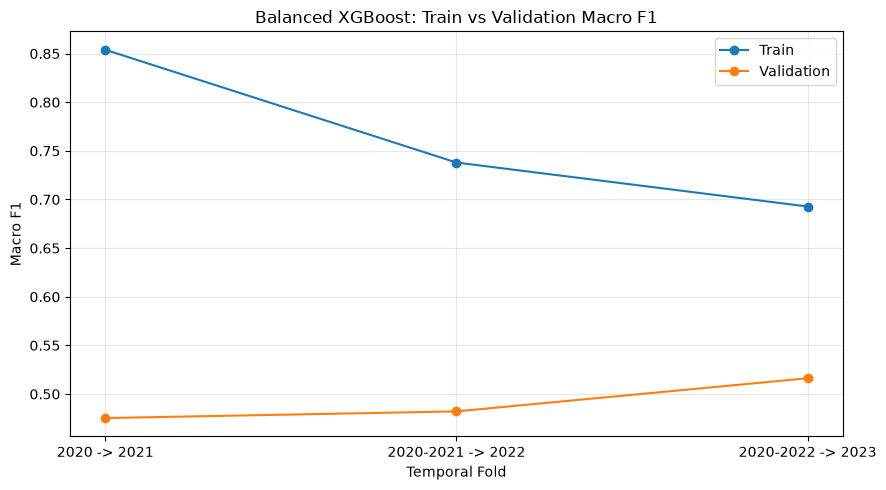

In [42]:
plot_train_validation_by_fold(
    results=balanced_xgboost_results,
    model_name="Balanced XGBoost",
    metric="macro_f1",
    metric_label="Macro F1",
)

#### Interpretation

Balanced XGBoost shows a noticeable train-validation gap, indicating overfitting.

However, the gap decreases substantially as more historical training data becomes available, from 0.379 in the first fold to 0.177 in the final fold. Validation Macro F1 also improves from 0.475 to 0.516.

This suggests that XGBoost benefits strongly from additional training data, although its generalization gap remains considerably larger than that observed for Balanced CatBoost.

## Shortlist Comparison

The shortlisted models are compared using validation Macro F1 and their train-validation generalization gaps.

### Generalization Comparison

In [43]:
shortlist_results = {
    "Balanced CatBoost":
        balanced_catboost_results,
    "Balanced Random Forest":
        balanced_random_forest_results,
    "Balanced XGBoost":
        balanced_xgboost_results,
}

comparison_rows = []

for model_name, results in (
    shortlist_results.items()
):
    comparison_rows.append({
        "model": model_name,
        "train_macro_f1":
            results[
                "train_macro_f1"
            ].mean(),
        "validation_macro_f1":
            results[
                "validation_macro_f1"
            ].mean(),
        "validation_macro_f1_std":
            results[
                "validation_macro_f1"
            ].std(),
        "macro_f1_gap":
            results[
                "macro_f1_gap"
            ].mean(),
    })

shortlist_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
)

shortlist_comparison.round(3)

,train_macro_f1,validation_macro_f1,validation_macro_f1_std,macro_f1_gap
model,,,,
Balanced CatBoost,0.667,0.483,0.021,0.184
Balanced Random Forest,0.989,0.494,0.012,0.495
Balanced XGBoost,0.762,0.491,0.022,0.270


### Interpretation

Random Forest achieves the highest raw mean validation Macro F1 among the shortlisted models at 0.494, narrowly ahead of XGBoost at 0.491 and Balanced CatBoost at 0.483.

Balanced CatBoost has by far the smallest train-validation generalization gap at 0.184, compared to 0.495 for Random Forest and 0.270 for XGBoost.

CatBoost led model screening in the previous baseline-screening notebook. Here, all three shortlisted models are re-evaluated using the compute backend described above (CatBoost on GPU), and the raw validation ranking shifts slightly: Random Forest edges ahead on raw Macro F1, while CatBoost keeps the best generalization behavior.

Because Random Forest shows severe overfitting and CatBoost offers the best balance of validation performance and generalization, Balanced CatBoost is tuned first, followed by Random Forest and XGBoost for a fair model-family comparison.

## Hyperparameter Tuning

This notebook performs reference (coarse) hyperparameter tuning to obtain strong, comparable configurations for each shortlisted model family. The goal is a fair model-family comparison, not a final production configuration. Final hyperparameter tuning will be repeated after feature experiments, once the feature set is finalized.

Hyperparameters are selected using temporal validation within the earlier development years.

The tuning folds are:

- Train on 2020, validate on 2021.
- Train on 2020-2021, validate on 2022.

The year 2023 is excluded from hyperparameter selection and is used afterward as a development validation year.

The 2024 final holdout remains sealed as the untouched final evaluation set and is not loaded or inspected anywhere in this notebook.

GPU acceleration is used during model optimization. Baseline configurations are re-evaluated using the same compute backend before comparison with tuned configurations.

### Tuning Validation

In [44]:
TUNING_FOLDS = [
    {
        "name": "2020 -> 2021",
        "train_years": [2020],
        "validation_year": 2021,
    },
    {
        "name": "2020-2021 -> 2022",
        "train_years": [2020, 2021],
        "validation_year": 2022,
    },
]

### Tuning Helpers

CatBoost configurations are evaluated using the earlier temporal tuning folds.

Training uses balanced class weights, while early stopping is based on unweighted Macro F1 to match the project's primary evaluation metric.

A high iteration ceiling allows the effective number of boosting iterations to be selected independently within each fold.

In [45]:
CATBOOST_MAX_ITERATIONS = 1500
CATBOOST_EARLY_STOPPING_ROUNDS = 100


def evaluate_catboost_tuning_configuration(
    params: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
) -> pd.DataFrame:
    rows = []

    for fold in TUNING_FOLDS:
        train_mask = years.isin(
            fold["train_years"]
        )
        validation_mask = years.eq(
            fold["validation_year"]
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        X_validation = X.loc[
            validation_mask
        ]
        y_validation = y.loc[
            validation_mask
        ]

        model = CatBoostClassifier(
            iterations=CATBOOST_MAX_ITERATIONS,
            loss_function="MultiClass",
            eval_metric=(
                "TotalF1:"
                "average=Macro;"
                "use_weights=False"
            ),
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
            **CATBOOST_DEVICE_PARAMS,
            **params,
        )

        model.fit(
            X_train,
            y_train,
            cat_features=list(X.columns),
            eval_set=(
                X_validation,
                y_validation,
            ),
            early_stopping_rounds=(
                CATBOOST_EARLY_STOPPING_ROUNDS
            ),
            use_best_model=True,
        )

        validation_pred = np.asarray(
            model.predict(X_validation)
        ).ravel()

        metrics = calculate_metrics(
            y_validation,
            validation_pred,
        )

        rows.append({
            "fold": fold["name"],
            "validation_macro_f1":
                metrics["macro_f1"],
            "best_iteration":
                model.get_best_iteration() + 1,
        })

    return pd.DataFrame(rows)

In [46]:
def run_catboost_tuning_search(
    search_space: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
):
    summary_rows = []
    detailed_results = []

    configurations = product(
        search_space["learning_rate"],
        search_space["depth"],
        search_space["l2_leaf_reg"],
    )

    for learning_rate, depth, l2_leaf_reg in configurations:
        params = {
            "learning_rate": learning_rate,
            "depth": depth,
            "l2_leaf_reg": l2_leaf_reg,
        }

        results = evaluate_catboost_tuning_configuration(
            params=params,
            X=X,
            y=y,
            years=years,
        )

        results = results.copy()
        results["learning_rate"] = learning_rate
        results["depth"] = depth
        results["l2_leaf_reg"] = l2_leaf_reg

        detailed_results.append(results)

        summary_rows.append({
            "learning_rate": learning_rate,
            "depth": depth,
            "l2_leaf_reg": l2_leaf_reg,
            "mean_validation_macro_f1":
                results["validation_macro_f1"].mean(),
            "std_validation_macro_f1":
                results["validation_macro_f1"].std(),
            "mean_best_iteration":
                results["best_iteration"].mean(),
        })

    summary = pd.DataFrame(summary_rows)
    summary = summary.sort_values(
        "mean_validation_macro_f1",
        ascending=False,
    ).reset_index(drop=True)

    details = pd.concat(
        detailed_results,
        ignore_index=True,
    )

    return summary, details

In [47]:
def run_random_forest_tuning_search(
    search_space: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
):
    summary_rows = []
    detailed_results = []

    configurations = product(
        search_space["max_depth"],
        search_space["min_samples_leaf"],
        search_space["min_samples_split"],
        search_space["max_features"],
    )

    for (
        max_depth,
        min_samples_leaf,
        min_samples_split,
        max_features,
    ) in configurations:
        params = {
            "max_depth":
                max_depth,
            "min_samples_leaf":
                min_samples_leaf,
            "min_samples_split":
                min_samples_split,
            "max_features":
                max_features,
        }

        results = (
            evaluate_random_forest_tuning_configuration(
                params=params,
                X=X,
                y=y,
                years=years,
            )
        )

        results = results.copy()

        for param_name, value in params.items():
            results[param_name] = value

        detailed_results.append(
            results
        )

        summary_rows.append({
            **params,
            "mean_train_macro_f1":
                results[
                    "train_macro_f1"
                ].mean(),
            "mean_validation_macro_f1":
                results[
                    "validation_macro_f1"
                ].mean(),
            "std_validation_macro_f1":
                results[
                    "validation_macro_f1"
                ].std(),
            "mean_macro_f1_gap":
                results[
                    "macro_f1_gap"
                ].mean(),
        })

    summary = pd.DataFrame(
        summary_rows
    )

    summary = summary.sort_values(
        "mean_validation_macro_f1",
        ascending=False,
    ).reset_index(drop=True)

    details = pd.concat(
        detailed_results,
        ignore_index=True,
    )

    return summary, details

#### Random Forest Tuning

Random Forest configurations are evaluated using the same temporal tuning folds.

The search focuses on tree regularization because the baseline model showed a very large train-validation Macro F1 gap.

In [48]:
def evaluate_random_forest_tuning_configuration(
    params: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
) -> pd.DataFrame:
    rows = []

    for fold in TUNING_FOLDS:
        train_mask = years.isin(
            fold["train_years"]
        )
        validation_mask = years.eq(
            fold["validation_year"]
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        X_validation = X.loc[
            validation_mask
        ]
        y_validation = y.loc[
            validation_mask
        ]

        model = Pipeline([
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=300,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                    **params,
                ),
            ),
        ])

        model.fit(
            X_train,
            y_train,
        )

        train_pred = model.predict(
            X_train
        )

        validation_pred = model.predict(
            X_validation
        )

        train_metrics = calculate_metrics(
            y_train,
            train_pred,
        )

        validation_metrics = calculate_metrics(
            y_validation,
            validation_pred,
        )

        rows.append({
            "fold": fold["name"],
            "train_macro_f1":
                train_metrics["macro_f1"],
            "validation_macro_f1":
                validation_metrics["macro_f1"],
            "macro_f1_gap":
                train_metrics["macro_f1"]
                - validation_metrics["macro_f1"],
        })

    return pd.DataFrame(rows)

#### XGBoost Tuning

XGBoost uses the same temporal tuning folds and Macro F1 selection criterion as the other shortlisted models.

Preprocessing is fitted independently within each training fold before transforming the corresponding validation year.

In [49]:
def xgboost_macro_f1_loss(
    y_true,
    y_pred,
) -> float:
    y_pred = np.asarray(y_pred)

    if y_pred.ndim == 1:
        if len(y_pred) == len(y_true):
            y_pred_labels = y_pred.astype(int)
        else:
            y_pred_labels = y_pred.reshape(
                len(y_true),
                len(CLASS_LABELS),
            ).argmax(axis=1)
    else:
        y_pred_labels = y_pred.argmax(axis=1)

    macro_f1 = f1_score(
        y_true,
        y_pred_labels,
        labels=CLASS_LABELS,
        average="macro",
        zero_division=0,
    )

    return 1 - macro_f1

In [50]:
XGBOOST_MAX_ESTIMATORS = 1500
XGBOOST_EARLY_STOPPING_ROUNDS = 100


def evaluate_xgboost_tuning_configuration(
    params: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
    folds,
) -> pd.DataFrame:
    rows = []

    for fold in folds:
        train_mask = years.isin(
            fold["train_years"]
        )
        validation_mask = years.eq(
            fold["validation_year"]
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        X_validation = X.loc[
            validation_mask
        ]
        y_validation = y.loc[
            validation_mask
        ]

        fold_preprocessor = clone(
            preprocessor
        )

        X_train_prepared = (
            fold_preprocessor.fit_transform(
                X_train
            )
        )

        X_validation_prepared = (
            fold_preprocessor.transform(
                X_validation
            )
        )

        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train,
        )

        model = XGBClassifier(
            n_estimators=XGBOOST_MAX_ESTIMATORS,
            objective="multi:softprob",
            eval_metric=xgboost_macro_f1_loss,
            early_stopping_rounds=
                XGBOOST_EARLY_STOPPING_ROUNDS,
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            **XGBOOST_DEVICE_PARAMS,
            **params,
        )

        model.fit(
            X_train_prepared,
            y_train,
            sample_weight=sample_weights,
            eval_set=[
                (
                    X_validation_prepared,
                    y_validation,
                )
            ],
            verbose=False,
        )

        best_iteration = (
            model.best_iteration + 1
        )

        train_pred = model.predict(
            X_train_prepared,
            iteration_range=(
                0,
                best_iteration,
            ),
        )

        validation_pred = model.predict(
            X_validation_prepared,
            iteration_range=(
                0,
                best_iteration,
            ),
        )

        train_metrics = calculate_metrics(
            y_train,
            train_pred,
        )

        validation_metrics = calculate_metrics(
            y_validation,
            validation_pred,
        )

        rows.append({
            "fold": fold["name"],
            "train_macro_f1":
                train_metrics["macro_f1"],
            "validation_macro_f1":
                validation_metrics["macro_f1"],
            "macro_f1_gap":
                train_metrics["macro_f1"]
                - validation_metrics["macro_f1"],
            "best_iteration":
                best_iteration,
        })

    return pd.DataFrame(rows)

### Balanced CatBoost Tuning

CatBoost is tuned first because it achieved the strongest baseline validation performance and the smallest generalization gap.

The initial search focuses on learning rate, tree depth, L2 regularization, and the effective number of boosting iterations.

#### Initial Configuration

An initial configuration is evaluated with a higher iteration ceiling and early stopping before exploring the hyperparameter search space.

In [51]:
catboost_initial_tuning_params = {
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3,
}

catboost_initial_tuning_results = evaluate_catboost_tuning_configuration(
    params=catboost_initial_tuning_params,
    X=X_catboost,
    y=y,
    years=years,
)

catboost_initial_tuning_results.round(4)

,fold,validation_macro_f1,best_iteration
0,2020 -> 2021,0.4759,491
1,2020-2021 -> 2022,0.4833,340


In [52]:
catboost_initial_tuning_summary = pd.Series({
    "mean_validation_macro_f1":
        catboost_initial_tuning_results[
            "validation_macro_f1"
        ].mean(),
    "std_validation_macro_f1":
        catboost_initial_tuning_results[
            "validation_macro_f1"
        ].std(),
    "mean_best_iteration":
        catboost_initial_tuning_results[
            "best_iteration"
        ].mean(),
})

catboost_initial_tuning_summary.round(4)

mean_validation_macro_f1      0.4796
std_validation_macro_f1       0.0052
mean_best_iteration         415.5000
dtype: float64

#### Initial Configuration Results

The initial tuning configuration achieved a mean validation Macro F1 of 0.4796 (std 0.0052), with best iterations of 491 and 340 in the two tuning folds under early stopping.

Because the search space below varies learning rate and tree depth substantially, a higher maximum of 1500 iterations with early stopping is retained so that each configuration's effective iteration count can be determined independently, rather than being constrained by the original 500-iteration baseline limit.

#### Search Space

The tuning search evaluates learning rate, tree depth, and L2 regularization.

The depth range extends beyond the strongest baseline region to verify whether additional tree complexity improves temporal validation performance.

The maximum number of iterations remains fixed at 1500, while early stopping determines the effective iteration count independently for each temporal fold.

In [53]:
CATBOOST_SEARCH_SPACE = {
    "learning_rate": [0.03, 0.05, 0.08],
    "depth": [4, 6, 8, 9, 10],
    "l2_leaf_reg": [3, 7, 12],
}

#### Tuning Search

All configurations are evaluated using the two temporal tuning folds and ranked primarily by mean validation Macro F1.

In [54]:
catboost_tuning_summary, catboost_tuning_details = run_catboost_tuning_search(
    search_space=CATBOOST_SEARCH_SPACE,
    X=X_catboost,
    y=y,
    years=years,
)

#### Top Configurations

In [55]:
catboost_tuning_summary.head(10).round(4)

,learning_rate,depth,l2_leaf_reg,mean_validation_macro_f1,std_validation_macro_f1,mean_best_iteration
0,0.03,9,12,0.4970,0.0166,583.5
1,0.03,9,3,0.4959,0.0240,509.5
2,0.05,8,7,0.4929,0.0230,559.0
3,0.03,10,3,0.4929,0.0224,447.5
4,0.08,10,12,0.4928,0.0172,388.5
5,0.03,8,3,0.4927,0.0204,754.5
6,0.05,10,3,0.4920,0.0203,316.5
7,0.08,8,12,0.4916,0.0187,381.0
8,0.08,8,3,0.4908,0.0190,245.5
9,0.05,9,3,0.4902,0.0209,224.0


#### Tuning Results

The strongest configuration uses a learning rate of 0.03, depth 9, and L2 regularization of 12, achieving a mean validation Macro F1 of 0.4970.

Several configurations perform similarly, so the result does not indicate a sharply defined optimum. However, the best configuration also shows relatively low variation across the temporal tuning folds.

Because performance does not continue improving at the upper depth boundary, the search is not expanded further.

#### Selected Configuration

In [56]:
CATBOOST_SELECTED_PARAMS = {
    "learning_rate": 0.03,
    "depth": 9,
    "l2_leaf_reg": 12,
}

In [57]:
selected_catboost_tuning_details = catboost_tuning_details[
    (catboost_tuning_details["learning_rate"] == 0.03)
    & (catboost_tuning_details["depth"] == 9)
    & (catboost_tuning_details["l2_leaf_reg"] == 12)
]

selected_catboost_tuning_details[
    [
        "fold",
        "validation_macro_f1",
        "best_iteration",
    ]
].round(4)

,fold,validation_macro_f1,best_iteration
22,2020 -> 2021,0.4852,433
23,2020-2021 -> 2022,0.5087,734


### Selected Configuration Iteration Analysis

After selecting the CatBoost hyperparameters, the configuration is evaluated across all development temporal folds with early stopping.

This analysis estimates the effective number of boosting iterations as the amount of training data increases.

The 2024 final holdout remains sealed and is not used for iteration selection.

In [58]:
def evaluate_selected_catboost_iterations(
    params: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
) -> pd.DataFrame:
    rows = []

    for fold in TEMPORAL_FOLDS:
        train_mask = years.isin(
            fold["train_years"]
        )
        validation_mask = years.eq(
            fold["validation_year"]
        )

        X_train = X.loc[train_mask]
        y_train = y.loc[train_mask]

        X_validation = X.loc[
            validation_mask
        ]
        y_validation = y.loc[
            validation_mask
        ]

        model = CatBoostClassifier(
            iterations=CATBOOST_MAX_ITERATIONS,
            loss_function="MultiClass",
            eval_metric=(
                "TotalF1:"
                "average=Macro;"
                "use_weights=False"
            ),
            auto_class_weights="Balanced",
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
            **CATBOOST_DEVICE_PARAMS,
            **params,
        )

        model.fit(
            X_train,
            y_train,
            cat_features=list(X.columns),
            eval_set=(
                X_validation,
                y_validation,
            ),
            early_stopping_rounds=
                CATBOOST_EARLY_STOPPING_ROUNDS,
            use_best_model=True,
        )

        validation_pred = np.asarray(
            model.predict(X_validation)
        ).ravel()

        metrics = calculate_metrics(
            y_validation,
            validation_pred,
        )

        rows.append({
            "fold": fold["name"],
            "validation_macro_f1":
                metrics["macro_f1"],
            "best_iteration":
                model.get_best_iteration() + 1,
        })

    return pd.DataFrame(rows)

In [59]:
selected_catboost_iteration_results = evaluate_selected_catboost_iterations(
    params=CATBOOST_SELECTED_PARAMS,
    X=X_catboost,
    y=y,
    years=years,
)

selected_catboost_iteration_results.round(4)

,fold,validation_macro_f1,best_iteration
0,2020 -> 2021,0.4852,433
1,2020-2021 -> 2022,0.5087,734
2,2020-2022 -> 2023,0.5261,776


#### Iteration Analysis Results

The selected configuration requires more boosting iterations as the amount of training data increases.

The best iteration increases from 433 in the first fold to 734 and then 776 in the later folds, suggesting that the required number of iterations begins to stabilize as more historical data becomes available.

The latest development fold (2020-2022 -> 2023) selected 776 iterations. This is not treated as a final iteration count: the effective number of boosting iterations will be revisited after feature selection and final hyperparameter tuning, since the feature set and resulting optimal configuration are expected to change.

### CatBoost Tuning Summary

The tuned CatBoost configuration is compared against the GPU baseline across all three development temporal folds.

In [60]:
catboost_tuning_comparison = pd.DataFrame({
    "fold": selected_catboost_iteration_results["fold"],
    "baseline_macro_f1": balanced_catboost_results[
        "validation_macro_f1"
    ].to_numpy(),
    "tuned_macro_f1": selected_catboost_iteration_results[
        "validation_macro_f1"
    ].to_numpy(),
})

catboost_tuning_comparison["improvement"] = (
    catboost_tuning_comparison["tuned_macro_f1"]
    - catboost_tuning_comparison["baseline_macro_f1"]
)

catboost_tuning_comparison.round(4)

,fold,baseline_macro_f1,tuned_macro_f1,improvement
0,2020 -> 2021,0.4655,0.4852,0.0197
1,2020-2021 -> 2022,0.4765,0.5087,0.0323
2,2020-2022 -> 2023,0.5068,0.5261,0.0193


The tuned CatBoost configuration improves Macro F1 across all three temporal folds.

Mean validation Macro F1 increases from 0.4829 for the GPU baseline to 0.5067 after tuning, an improvement of 0.0237.

The improvement is consistent across all development folds, ranging from 0.0193 to 0.0323 Macro F1.

### Balanced Random Forest Tuning

The search focuses on parameters that control individual tree complexity and regularization.

The number of trees remains fixed at 300 while depth, minimum sample requirements, and feature sampling are tuned.

#### Search Space

In [61]:
RANDOM_FOREST_SEARCH_SPACE = {
    "max_depth": [
        8,
        12,
        16,
        None,
    ],
    "min_samples_leaf": [
        1,
        5,
        15,
    ],
    "min_samples_split": [
        2,
        10,
    ],
    "max_features": [
        "sqrt",
        0.5,
    ],
}

#### Tuning Search

All configurations are evaluated using the two temporal tuning folds and ranked by mean validation Macro F1.

In [62]:
random_forest_tuning_summary, random_forest_tuning_details = run_random_forest_tuning_search(
    search_space=RANDOM_FOREST_SEARCH_SPACE,
    X=X,
    y=y,
    years=years,
)

#### Top Configurations

In [63]:
random_forest_tuning_summary.head(10).round(4)

,max_depth,min_samples_leaf,min_samples_split,max_features,mean_train_macro_f1,mean_validation_macro_f1,std_validation_macro_f1,mean_macro_f1_gap
0,NaN,1,10,sqrt,0.8301,0.4980,0.0140,0.3320
1,16.0,1,2,sqrt,0.7559,0.4977,0.0042,0.2582
2,16.0,1,10,sqrt,0.6503,0.4917,0.0063,0.1586
3,NaN,1,2,sqrt,0.9903,0.4884,0.0102,0.5019
4,16.0,1,2,0.5,0.7472,0.4880,0.0141,0.2592
5,NaN,5,10,0.5,0.7020,0.4879,0.0140,0.2142
6,NaN,5,2,0.5,0.7020,0.4879,0.0140,0.2142
7,NaN,5,10,sqrt,0.6148,0.4865,0.0110,0.1283
8,NaN,5,2,sqrt,0.6148,0.4865,0.0110,0.1283
9,12.0,1,2,sqrt,0.6094,0.4837,0.0021,0.1257


#### Tuning Results

Random Forest regularization substantially reduces the train-validation gap while maintaining competitive validation performance.

The top-ranked configuration (unlimited depth) achieves a mean validation Macro F1 of about 0.4980. The selected depth-16 configuration scores about 0.4977, a negligible difference of roughly 0.0003.

Depth 16 is selected instead of the top row because it has a substantially smaller generalization gap (0.2582 vs 0.3320) and much lower variation across temporal folds (std 0.0042 vs 0.0140), at an essentially identical validation score.

Based on this reference tuning alone, Random Forest and the tuned CatBoost configuration achieve essentially equal mean validation Macro F1. The three-fold tuned model comparison later in this notebook resolves the ranking between model families.

#### Selected Configuration

In [64]:
RANDOM_FOREST_SELECTED_PARAMS = {
    "max_depth": 16,
    "min_samples_leaf": 1,
    "min_samples_split": 2,
    "max_features": "sqrt",
}

#### Selected Configuration Evaluation

The selected Random Forest configuration is evaluated across all development temporal folds before the final reference model comparison.

In [65]:
selected_random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor,
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            **RANDOM_FOREST_SELECTED_PARAMS,
        ),
    ),
])

In [66]:
selected_random_forest_results, selected_random_forest_predictions, selected_random_forest_models = evaluate_detailed_temporal_cv(
    model=selected_random_forest_model,
    model_name="Tuned Random Forest",
    X=X,
    y=y,
    years=years,
)

In [67]:
selected_random_forest_results[
    [
        "fold",
        "train_macro_f1",
        "validation_macro_f1",
        "macro_f1_gap",
    ]
].round(4)

,fold,train_macro_f1,validation_macro_f1,macro_f1_gap
0,2020 -> 2021,0.7983,0.4947,0.3036
1,2020-2021 -> 2022,0.7136,0.5007,0.2129
2,2020-2022 -> 2023,0.6782,0.5260,0.1523


### Balanced XGBoost Tuning

XGBoost is tuned using the same temporal validation strategy to provide a fair comparison between the shortlisted model families.

The search focuses on learning rate, tree complexity, and row and feature sampling. A high estimator ceiling with early stopping determines the effective number of boosting rounds.

#### Search Space

The search evaluates learning rate, tree complexity, minimum child weight, row sampling, and feature sampling.

The depth and subsample ranges are extended beyond the strongest region observed during preliminary experimentation to verify whether additional complexity or stronger row sampling improves temporal validation performance.

A high estimator ceiling with early stopping determines the effective number of boosting rounds.

In [68]:
XGBOOST_SEARCH_SPACE = {
    "learning_rate": [
        0.03,
        0.05,
        0.10,
    ],
    "max_depth": [
        4,
        6,
        8,
        10,
    ],
    "min_child_weight": [
        1,
        5,
    ],
    "subsample": [
        0.6,
        0.8,
        1.0,
    ],
    "colsample_bytree": [
        0.8,
        1.0,
    ],
}

In [69]:
def run_xgboost_tuning_search(
    search_space: dict,
    X: pd.DataFrame,
    y: pd.Series,
    years: pd.Series,
):
    summary_rows = []
    detailed_results = []

    configurations = list(product(
        search_space["learning_rate"],
        search_space["max_depth"],
        search_space["min_child_weight"],
        search_space["subsample"],
        search_space["colsample_bytree"],
    ))

    best_score = -np.inf

    progress = tqdm(
        configurations,
        desc="XGBoost tuning",
    )

    for (
        learning_rate,
        max_depth,
        min_child_weight,
        subsample,
        colsample_bytree,
    ) in progress:
        params = {
            "learning_rate": learning_rate,
            "max_depth": max_depth,
            "min_child_weight": min_child_weight,
            "subsample": subsample,
            "colsample_bytree": colsample_bytree,
        }

        results = evaluate_xgboost_tuning_configuration(
            params=params,
            X=X,
            y=y,
            years=years,
            folds=TUNING_FOLDS,
        )

        results = results.copy()

        for param_name, value in params.items():
            results[param_name] = value

        detailed_results.append(results)

        mean_validation_macro_f1 = results[
            "validation_macro_f1"
        ].mean()

        best_score = max(
            best_score,
            mean_validation_macro_f1,
        )

        summary_rows.append({
            **params,
            "mean_train_macro_f1":
                results["train_macro_f1"].mean(),
            "mean_validation_macro_f1":
                mean_validation_macro_f1,
            "std_validation_macro_f1":
                results["validation_macro_f1"].std(),
            "mean_macro_f1_gap":
                results["macro_f1_gap"].mean(),
            "mean_best_iteration":
                results["best_iteration"].mean(),
        })

        progress.set_postfix({
            "best_macro_f1": f"{best_score:.4f}",
            "depth": max_depth,
            "lr": learning_rate,
        })

    summary = pd.DataFrame(
        summary_rows
    )

    summary = summary.sort_values(
        "mean_validation_macro_f1",
        ascending=False,
    ).reset_index(drop=True)

    details = pd.concat(
        detailed_results,
        ignore_index=True,
    )

    return summary, details

#### Tuning Search

All configurations are evaluated using the two temporal tuning folds and ranked primarily by mean validation Macro F1.

In [70]:
xgboost_tuning_summary, xgboost_tuning_details = run_xgboost_tuning_search(
    search_space=XGBOOST_SEARCH_SPACE,
    X=X,
    y=y,
    years=years,
)

XGBoost tuning: 100%|██████████| 144/144 [39:09<00:00, 16.32s/it, best_macro_f1=0.5075, depth=10, lr=0.1] 


In [71]:
xgboost_tuning_summary.head(10).round(4)

,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,mean_train_macro_f1,mean_validation_macro_f1,std_validation_macro_f1,mean_macro_f1_gap,mean_best_iteration
0,0.05,10,5,0.6,1.0,0.6604,0.5075,0.0076,0.1529,110.5
1,0.03,10,5,0.6,1.0,0.6628,0.5054,0.0098,0.1574,183.0
2,0.05,10,5,0.6,0.8,0.6747,0.5040,0.0085,0.1707,128.5
3,0.03,10,5,0.6,0.8,0.6578,0.5037,0.0120,0.1541,188.0
4,0.05,10,1,0.6,1.0,0.7700,0.5036,0.0088,0.2664,166.0
5,0.10,10,1,0.8,0.8,0.8575,0.5035,0.0129,0.3540,122.5
6,0.05,10,1,0.6,0.8,0.7116,0.5029,0.0119,0.2087,114.5
7,0.05,10,1,0.8,0.8,0.8295,0.5026,0.0127,0.3269,209.0
8,0.03,10,5,0.8,1.0,0.6592,0.5021,0.0122,0.1571,170.5
9,0.03,8,1,0.6,1.0,0.6973,0.5017,0.0113,0.1956,300.5


#### Tuning Results

The strongest configuration uses a learning rate of 0.05, max depth 10, minimum child weight 5, subsample 0.6, and colsample_bytree 1.0, achieving a mean validation Macro F1 of 0.5075 (std 0.0076) with a mean train-validation gap of 0.1529.

The winning configuration is still at the depth and subsample boundaries of the search space (depth 10, subsample 0.6). No further reference tuning is performed here, because the feature set will change during feature experiments and final hyperparameter tuning will be repeated afterward on the resulting feature set.

#### Selected Configuration

The strongest reference configuration combines deeper trees with stronger row sampling and additional minimum child regularization.

This configuration is retained for evaluation across all development temporal folds before the reference model is selected.

In [72]:
XGBOOST_SELECTED_PARAMS = {
    "learning_rate": 0.05,
    "max_depth": 10,
    "min_child_weight": 5,
    "subsample": 0.6,
    "colsample_bytree": 1.0,
}

#### Selected Configuration Evaluation

The selected XGBoost configuration is evaluated across all development temporal folds to measure its performance and effective boosting iterations as additional historical training data becomes available.

In [73]:
selected_xgboost_results = evaluate_xgboost_tuning_configuration(
    params=XGBOOST_SELECTED_PARAMS,
    X=X,
    y=y,
    years=years,
    folds=TEMPORAL_FOLDS,
)

selected_xgboost_results.round(4)

,fold,train_macro_f1,validation_macro_f1,macro_f1_gap,best_iteration
0,2020 -> 2021,0.6047,0.5021,0.1026,31
1,2020-2021 -> 2022,0.7161,0.5128,0.2032,190
2,2020-2022 -> 2023,0.7276,0.5296,0.1981,254


## Tuned Model Comparison

The tuned model configurations are compared across all three development temporal folds (2020-2023) using validation Macro F1.

These folds are development data used for model-family and reference-configuration selection. They are not a final, unbiased performance estimate, since the same development years informed the earlier hyperparameter search. The 2024 final holdout remains untouched and sealed, reserved for final unbiased evaluation once the feature set and model are finalized.

The comparison focuses on relative performance after reference tuning, before experimental features are introduced.

In [74]:
tuned_model_fold_comparison = pd.DataFrame({
    "fold": selected_xgboost_results["fold"],
    "CatBoost": selected_catboost_iteration_results[
        "validation_macro_f1"
    ].to_numpy(),
    "Random Forest": selected_random_forest_results[
        "validation_macro_f1"
    ].to_numpy(),
    "XGBoost": selected_xgboost_results[
        "validation_macro_f1"
    ].to_numpy(),
})

tuned_model_fold_comparison.round(4)

,fold,CatBoost,Random Forest,XGBoost
0,2020 -> 2021,0.4852,0.4947,0.5021
1,2020-2021 -> 2022,0.5087,0.5007,0.5128
2,2020-2022 -> 2023,0.5261,0.5260,0.5296


### Performance Summary

In [75]:
tuned_model_summary = pd.DataFrame({
    "mean_validation_macro_f1": (
        tuned_model_fold_comparison[
            [
                "CatBoost",
                "Random Forest",
                "XGBoost",
            ]
        ].mean()
    ),
    "std_validation_macro_f1": (
        tuned_model_fold_comparison[
            [
                "CatBoost",
                "Random Forest",
                "XGBoost",
            ]
        ].std()
    ),
})

tuned_model_summary = tuned_model_summary.sort_values(
    "mean_validation_macro_f1",
    ascending=False,
)

tuned_model_summary.round(4)

,mean_validation_macro_f1,std_validation_macro_f1
XGBoost,0.5148,0.0138
Random Forest,0.5071,0.0166
CatBoost,0.5067,0.0205


### Interpretation

All three tuned models achieve similar temporal validation performance, with mean Macro F1 scores close to 0.51.

XGBoost achieves the highest mean validation Macro F1 and outperforms the other tuned models in each of the three temporal folds.

Random Forest and CatBoost achieve nearly identical mean performance, while XGBoost provides a small but consistent advantage across the development years.

XGBoost is therefore selected as the reference model for feature experiments. This selection is not final, because model hyperparameters and model family will be reconsidered after the final feature set is established.

## Reference Model Selection

Tuned XGBoost is selected as the reference model for feature experiments based on its consistently stronger temporal validation performance.

The same reference configuration will be held fixed while experimental features are evaluated. Final model tuning will be performed only after the feature set is selected.

### Tuning Improvement

Reference tuning improves validation Macro F1 across all three shortlisted model families.

In [76]:
tuning_improvement = pd.DataFrame({
    "baseline_macro_f1": {
        "CatBoost": balanced_catboost_results[
            "validation_macro_f1"
        ].mean(),
        "Random Forest": balanced_random_forest_results[
            "validation_macro_f1"
        ].mean(),
        "XGBoost": balanced_xgboost_results[
            "validation_macro_f1"
        ].mean(),
    },
    "tuned_macro_f1": {
        "CatBoost": selected_catboost_iteration_results[
            "validation_macro_f1"
        ].mean(),
        "Random Forest": selected_random_forest_results[
            "validation_macro_f1"
        ].mean(),
        "XGBoost": selected_xgboost_results[
            "validation_macro_f1"
        ].mean(),
    },
})

tuning_improvement["improvement"] = (
    tuning_improvement["tuned_macro_f1"]
    - tuning_improvement["baseline_macro_f1"]
)

tuning_improvement.round(4)

,baseline_macro_f1,tuned_macro_f1,improvement
CatBoost,0.4829,0.5067,0.0238
Random Forest,0.4939,0.5071,0.0133
XGBoost,0.4912,0.5148,0.0236


Reference tuning improves all three shortlisted models.

XGBoost achieves the strongest tuned validation performance and shows a consistent improvement over its baseline configuration. CatBoost also benefits substantially from tuning, while Random Forest improves more moderately.

These results support using tuned XGBoost as the reference model for the subsequent feature experiments.